# Sensorless Drive Diagnosis - Clasificación

Este notebook carga, explora, prepara y entrena modelos sobre el dataset
`EXAMEN/datasets/dataset+for+sensorless+drive+diagnosis/Sensorless_drive_diagnosis.txt`.

Objetivos:
- Cargar y explorar los datos
- Preprocesar y dividir en train/test
- Entrenar modelos de clasificación y evaluar
- Ajustar hiperparámetros y guardar el mejor modelo

Ruta del dataset usada en este notebook:
`EXAMEN/datasets/dataset+for+sensorless+drive+diagnosis/Sensorless_drive_diagnosis.txt`


In [34]:
# 1) Carga de librerías y configuración
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


In [35]:
# 2) Carga del dataset
dataset_path = os.path.join('EXAMEN','datasets','dataset+for+sensorless+drive+diagnosis','Sensorless_drive_diagnosis.txt')

# Leer usando un separador de espacios (regex) con engine='python'
# (algunas versiones/entornos no aceptan 'delim_whitespace')
try:
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, engine='python')
except Exception as e:
    print('Error al leer con sep regex:', e)
    # Intentar lectura por comas como fallback
    df = pd.read_csv(dataset_path, sep=',', header=None, engine='python')

# Si aún se leía todo en una sola columna, partir manualmente por espacios
if df.shape[1] == 1:
    try:
        df = df[0].astype(str).str.strip().str.split(r'\s+', expand=True)
        print('Se re-parseó el archivo dividiendo por espacios.' )
    except Exception as e:
        print('No se pudo re-parsar manualmente:', e)

print('Ruta usada:', dataset_path)
print('Shape:', df.shape)

# Si no hay nombres, asignar nombres genéricos
if df.columns.dtype == 'int64' or df.columns.isnull().any():
    df.columns = [f'X{i+1}' for i in range(df.shape[1])]

# Asumimos que la última columna es la etiqueta/clase
df.rename(columns={df.columns[-1]: 'class'}, inplace=True)

df.head()


Ruta usada: EXAMEN\datasets\dataset+for+sensorless+drive+diagnosis\Sensorless_drive_diagnosis.txt
Shape: (58509, 49)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X40,X41,X42,X43,X44,X45,X46,X47,X48,class
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


In [36]:
# 3) Inspección inicial de datos
print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes.value_counts())
print('\nValores nulos por columna:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

display(df.head())

df.describe().T


Dimensiones: (58509, 49)

Tipos de datos:
float64    48
int64       1
Name: count, dtype: int64

Valores nulos por columna:
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
dtype: int64


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X40,X41,X42,X43,X44,X45,X46,X47,X48,class
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


,count,mean,std,min,25%,50%,75%,max
X1,58509.0,-3.332852e-06,0.000072,-0.013721,-0.000007,-2.652600e-06,0.000002,0.005784
X2,58509.0,1.439648e-06,0.000056,-0.005414,-0.000014,8.804600e-07,0.000019,0.004525
X3,58509.0,1.412013e-06,0.000235,-0.013580,-0.000072,5.137700e-07,0.000075,0.005238
X4,58509.0,-1.312815e-06,0.000063,-0.012787,-0.000005,-1.059100e-06,0.000004,0.001453
X5,58509.0,1.351239e-06,0.000057,-0.008356,-0.000015,7.540200e-07,0.000019,0.000825
X6,58509.0,-2.654483e-07,0.000226,-0.009741,-0.000074,-1.659300e-07,0.000071,0.002754
X7,58509.0,1.914585e-03,0.036468,-0.139890,-0.019927,1.322600e-02,0.024770,0.069125
X8,58509.0,1.913146e-03,0.036465,-0.135940,-0.019951,1.323000e-02,0.024776,0.069130
X9,58509.0,1.911733e-03,0.036470,-0.130860,-0.019925,1.324700e-02,0.024777,0.069131
X10,58509.0,-1.189731e-02,0.066482,-0.218640,-0.032144,-1.556600e-02,0.020614,0.352580


Distribución de clases:
class
1     5319
2     5319
3     5319
4     5319
5     5319
6     5319
7     5319
8     5319
9     5319
10    5319
11    5319
Name: count, dtype: int64


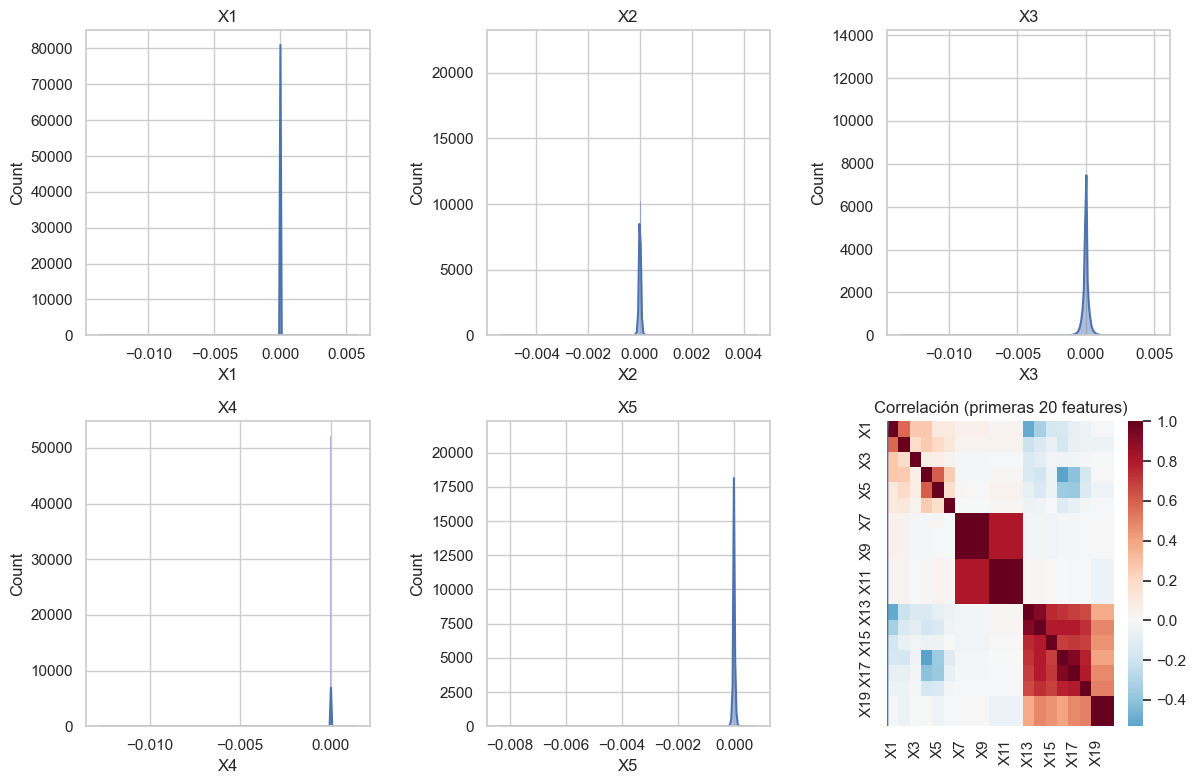

In [37]:
# 4) Análisis exploratorio básico
# Distribución de clases
print('Distribución de clases:')
print(df['class'].value_counts())

# Histograma de primeras 6 características
feat_cols = df.columns[:-1].tolist()
plt.figure(figsize=(12,8))
for i, col in enumerate(feat_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()

# Matriz de correlación (muestra un subset para no sobrecargar)
corr = df[feat_cols[:20]].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0)
plt.title('Correlación (primeras 20 features)')
plt.show()


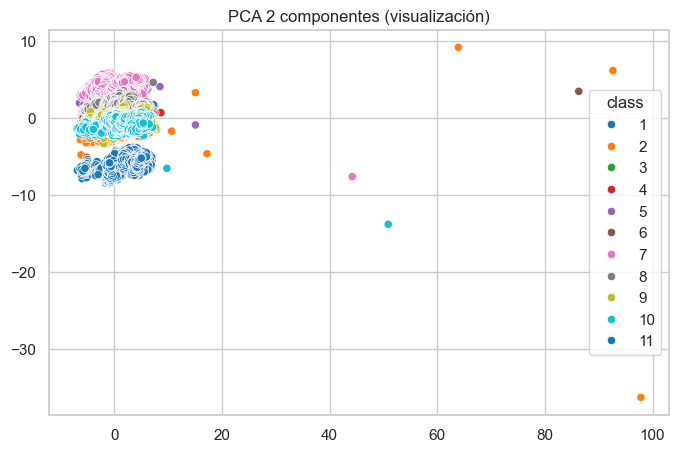

In [38]:
# 5) Preparación de variables y etiquetas
X = df.iloc[:, :-1]
y = df['class']

# Convertir etiquetas a numéricas si hace falta
if y.dtype == 'object' or not np.issubdtype(y.dtype, np.number):
    le = LabelEncoder()
    y = le.fit_transform(y)
    print('Etiquetas codificadas. Clases:', le.classes_)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA para visualización (opcional)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='tab10', legend='full')
plt.title('PCA 2 componentes (visualización)')
plt.show()


In [39]:
# 6) División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (46807, 48) Test shape: (11702, 48)


In [40]:
# 7) Entrenamiento de modelos de clasificación
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'report': classification_report(y_test, y_pred, zero_division=0)
    }

results


Entrenando LogisticRegression...
Entrenando RandomForest...


{'LogisticRegression': {'accuracy': 0.9189882071440779,
  'precision': 0.919003940065008,
  'recall': 0.9189882071440779,
  'f1': 0.918901856209167,
  'report': '              precision    recall  f1-score   support\n\n           1       0.96      0.96      0.96      1063\n           2       0.90      0.88      0.89      1064\n           3       0.96      0.96      0.96      1064\n           4       0.96      0.96      0.96      1064\n           5       0.86      0.82      0.84      1064\n           6       0.85      0.85      0.85      1063\n           7       1.00      1.00      1.00      1064\n           8       0.87      0.91      0.89      1064\n           9       0.87      0.87      0.87      1064\n          10       0.89      0.91      0.90      1064\n          11       1.00      1.00      1.00      1064\n\n    accuracy                           0.92     11702\n   macro avg       0.92      0.92      0.92     11702\nweighted avg       0.92      0.92      0.92     11702\n'},
 'Ran

## 7.1) Visualización 2D tipo lab7 (PCA + fronteras de decisión)

Para visualizar mejor el comportamiento de los modelos, proyectamos los datos a 2 dimensiones con PCA y entrenamos versiones de visualización de cada modelo sobre esas 2 componentes.

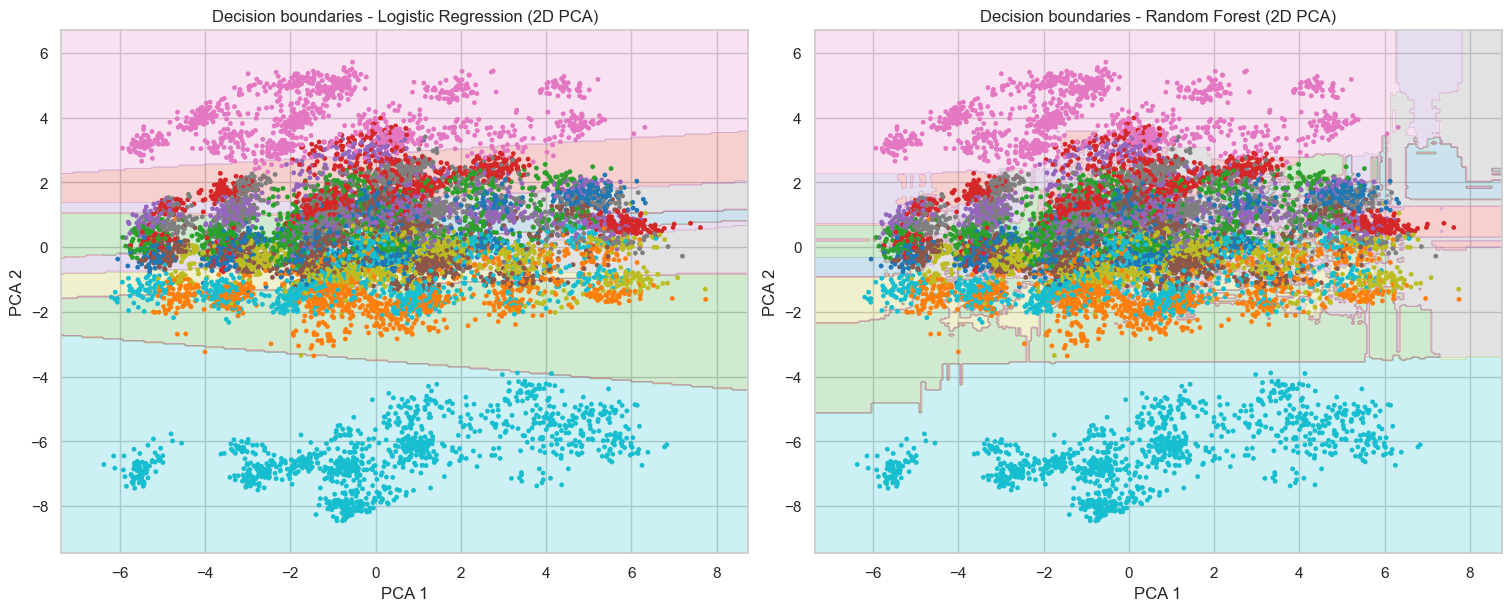

Variance explicada por PCA (2 componentes): 0.31408216561717045


In [41]:
# PCA 2D para visualización (ajuste solo con train)
pca_vis = PCA(n_components=2, random_state=42)
X_train_vis = pca_vis.fit_transform(X_train)
X_test_vis = pca_vis.transform(X_test)

# Modelos de visualización entrenados en 2D
logreg_vis = LogisticRegression(max_iter=1500, random_state=42)
rf_vis = RandomForestClassifier(n_estimators=120, random_state=42)

logreg_vis.fit(X_train_vis, y_train)
rf_vis.fit(X_train_vis, y_train)


def plot_decision_boundaries(model, X2, y_true, title, ax):
    x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
    y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 320),
        np.linspace(y_min, y_max, 320)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    n_classes = len(np.unique(y_true))
    cmap = plt.get_cmap('tab10', n_classes)

    ax.contourf(xx, yy, zz, alpha=0.22, cmap=cmap)
    ax.scatter(
        X2[:, 0],
        X2[:, 1],
        c=y_true,
        s=12,
        cmap=cmap,
        edgecolor='none'
    )

    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')


fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

plot_decision_boundaries(logreg_vis, X_test_vis, y_test, 'Decision boundaries - Logistic Regression (2D PCA)', axes[0])
plot_decision_boundaries(rf_vis, X_test_vis, y_test, 'Decision boundaries - Random Forest (2D PCA)', axes[1])

plt.show()

print('Variance explicada por PCA (2 componentes):', pca_vis.explained_variance_ratio_.sum())

## 7.2) Evolución de K-Means en 6 paneles (estilo lab7)

Esta visualización replica el formato de 6 subplots para ver cómo cambian centroides y fronteras en iteraciones sucesivas, usando una proyección PCA a 2D del dataset Sensorless.

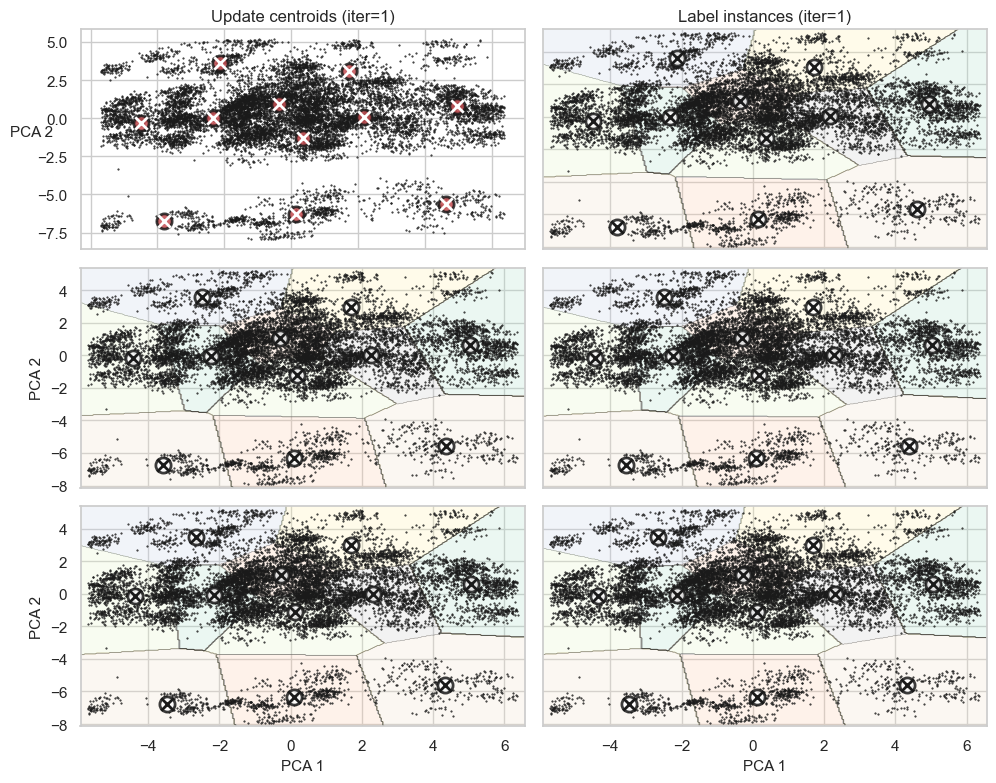

Muestras visualizadas (tras recorte robusto): 12000 de 46807


In [47]:
from sklearn.cluster import KMeans

# Datos 2D para visualización (ya calculados arriba)
X_vis_all = X_train_vis
k_vis = len(np.unique(y_train))

# Recorte robusto para evitar que outliers extremos aplasten la figura
x1_lo, x1_hi = np.percentile(X_vis_all[:, 0], [0.5, 99.5])
x2_lo, x2_hi = np.percentile(X_vis_all[:, 1], [0.5, 99.5])
mask_core = (
    (X_vis_all[:, 0] >= x1_lo) & (X_vis_all[:, 0] <= x1_hi) &
    (X_vis_all[:, 1] >= x2_lo) & (X_vis_all[:, 1] <= x2_hi)
)
X_vis = X_vis_all[mask_core]

# Submuestreo para acelerar y limpiar visualmente
rng = np.random.RandomState(42)
max_points = 12000
if len(X_vis) > max_points:
    idx = rng.choice(len(X_vis), size=max_points, replace=False)
    X_vis = X_vis[idx]

def plot_data_vis(X2):
    plt.plot(X2[:, 0], X2[:, 1], 'k.', markersize=1)

def plot_centroids_vis(centroids, circle_color='w', cross_color='k'):
    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        marker='o', s=120, linewidths=2,
        color=circle_color, edgecolor='k', zorder=10, alpha=0.85
    )
    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        marker='x', s=80, linewidths=2,
        color=cross_color, zorder=11
    )

def plot_decision_boundaries_vis(clusterer, X2, resolution=300, show_centroids=True,
                                 show_xlabels=True, show_ylabels=True):
    mins = X2.min(axis=0) - 0.2
    maxs = X2.max(axis=0) + 0.2
    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution)
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, cmap='Pastel2')
    plt.contour(xx, yy, Z, linewidths=0.35, colors='k', alpha=0.45)
    plot_data_vis(X2)
    if show_centroids:
        plot_centroids_vis(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel('PCA 1', fontsize=11)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel('PCA 2', fontsize=11)
    else:
        plt.tick_params(labelleft=False)

# Tres ejecuciones para mostrar evolución tipo lab7
kmeans_iter1 = KMeans(n_clusters=k_vis, init='k-means++', n_init=1, max_iter=1, random_state=7)
kmeans_iter2 = KMeans(n_clusters=k_vis, init='k-means++', n_init=1, max_iter=2, random_state=7)
kmeans_iter3 = KMeans(n_clusters=k_vis, init='k-means++', n_init=1, max_iter=3, random_state=7)

kmeans_iter1.fit(X_vis)
kmeans_iter2.fit(X_vis)
kmeans_iter3.fit(X_vis)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data_vis(X_vis)
plot_centroids_vis(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel('PCA 2', fontsize=11, rotation=0)
plt.tick_params(labelbottom=False)
plt.title('Update centroids (iter=1)', fontsize=12)

plt.subplot(322)
plot_decision_boundaries_vis(kmeans_iter1, X_vis, show_xlabels=False, show_ylabels=False)
plt.title('Label instances (iter=1)', fontsize=12)

plt.subplot(323)
plot_decision_boundaries_vis(kmeans_iter1, X_vis, show_centroids=False, show_xlabels=False)
plot_centroids_vis(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries_vis(kmeans_iter2, X_vis, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries_vis(kmeans_iter2, X_vis, show_centroids=False)
plot_centroids_vis(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries_vis(kmeans_iter3, X_vis, show_ylabels=False)

plt.tight_layout()
plt.show()

print('Muestras visualizadas (tras recorte robusto):', len(X_vis), 'de', len(X_vis_all))

## 7.3) Visualización 3D (PCA) para mejor entendimiento

Se proyectan los datos a 3 componentes principales y se comparan clases reales vs clusters K-Means en 3D.

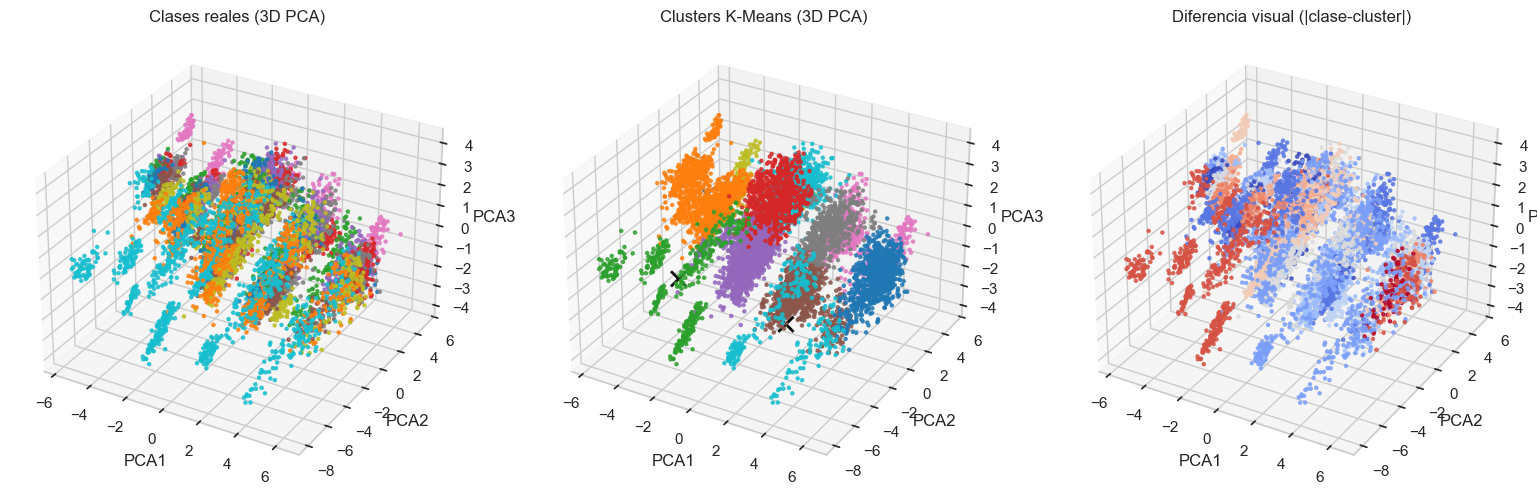

Varianza explicada por PCA 3D: 0.40293321782128344
Muestras usadas en 3D: 9000 de 46807


In [48]:
# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_train_3d_all = pca_3d.fit_transform(X_train)

# Recorte robusto en 3D para mejorar legibilidad
p_lo = np.percentile(X_train_3d_all, 0.5, axis=0)
p_hi = np.percentile(X_train_3d_all, 99.5, axis=0)
mask_3d = np.all((X_train_3d_all >= p_lo) & (X_train_3d_all <= p_hi), axis=1)
X_train_3d = X_train_3d_all[mask_3d]
y_train_3d = np.asarray(y_train)[mask_3d]

# Submuestreo para visualización rápida
rng3 = np.random.RandomState(42)
max_points_3d = 9000
if len(X_train_3d) > max_points_3d:
    idx3 = rng3.choice(len(X_train_3d), size=max_points_3d, replace=False)
    X_train_3d = X_train_3d[idx3]
    y_train_3d = y_train_3d[idx3]

# KMeans sobre 3D para comparar con clases reales
k_vis_3d = len(np.unique(y_train_3d))
kmeans_3d = KMeans(n_clusters=k_vis_3d, init='k-means++', n_init=10, random_state=42)
clusters_3d = kmeans_3d.fit_predict(X_train_3d)
centers_3d = kmeans_3d.cluster_centers_

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(
    X_train_3d[:, 0], X_train_3d[:, 1], X_train_3d[:, 2],
    c=y_train_3d, s=5, cmap='tab10', alpha=0.8
)
ax1.set_title('Clases reales (3D PCA)')
ax1.set_xlabel('PCA1')
ax1.set_ylabel('PCA2')
ax1.set_zlabel('PCA3')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(
    X_train_3d[:, 0], X_train_3d[:, 1], X_train_3d[:, 2],
    c=clusters_3d, s=5, cmap='tab10', alpha=0.8
)
ax2.scatter(
    centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2],
    c='black', marker='x', s=120, linewidths=2
)
ax2.set_title('Clusters K-Means (3D PCA)')
ax2.set_xlabel('PCA1')
ax2.set_ylabel('PCA2')
ax2.set_zlabel('PCA3')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(
    X_train_3d[:, 0], X_train_3d[:, 1], X_train_3d[:, 2],
    c=np.abs(y_train_3d - clusters_3d), s=5, cmap='coolwarm', alpha=0.8
)
ax3.set_title('Diferencia visual (|clase-cluster|)')
ax3.set_xlabel('PCA1')
ax3.set_ylabel('PCA2')
ax3.set_zlabel('PCA3')

plt.tight_layout()
plt.show()

print('Varianza explicada por PCA 3D:', pca_3d.explained_variance_ratio_.sum())
print('Muestras usadas en 3D:', len(X_train_3d), 'de', len(X_train_3d_all))

Entrenando k=2...
Entrenando k=3...
Entrenando k=5...
Entrenando k=7...
Entrenando k=10...
Entrenando k=12...
Entrenando k=15...
Entrenando k=20...


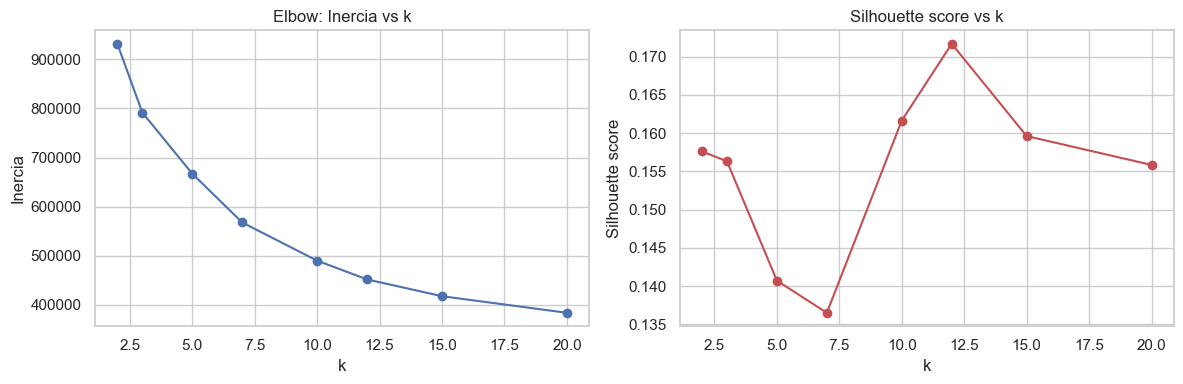

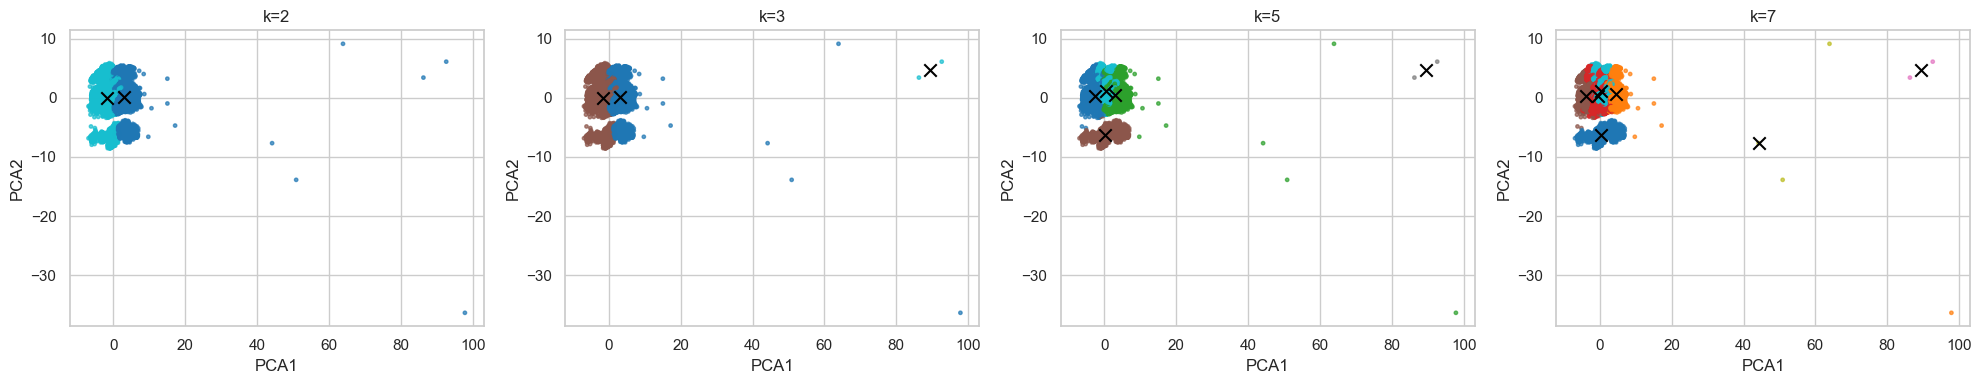

Hecho. Modifica la lista `ks` si quieres probar otros valores.


In [49]:
# Prueba múltiple de k para KMeans: inertia + silhouette + visualizaciones PCA 2D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Valores de k a probar (puedes modificarlos)
ks = [2, 3, 5, 7, 10, 12, 15, 20]

# Para velocidad, muestreamos si el dataset es grande
X_for_clustering = X_scaled if 'X_scaled' in globals() else X.values
sample_size = 20000
if len(X_for_clustering) > sample_size:
    rng = np.random.RandomState(42)
    idx_sample = rng.choice(len(X_for_clustering), size=sample_size, replace=False)
    X_sample = X_for_clustering[idx_sample]
else:
    X_sample = X_for_clustering

inertias = []
sil_scores = []
models_k = {}

for k in ks:
    print(f"Entrenando k={k}...")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    if k > 1:
        try:
            sil = silhouette_score(X_sample, km.labels_, metric='euclidean')
        except Exception:
            sil = float('nan')
    else:
        sil = float('nan')
    sil_scores.append(sil)
    models_k[k] = km

# Plot Elbow + Silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Elbow: Inercia vs k')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs k')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualizar algunos k seleccionados (hasta 4) en PCA 2D
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_for_clustering if len(X_for_clustering.shape)==2 else X_for_clustering.values)

show_ks = ks[:4]
fig, axes = plt.subplots(1, len(show_ks), figsize=(5*len(show_ks),4))
if len(show_ks) == 1:
    axes = [axes]
for ax, k in zip(axes, show_ks):
    km = models_k[k]
    labels = km.predict(X_for_clustering)
    sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=labels, s=6, cmap='tab10', alpha=0.7)
    # plot centroids in PCA space (transform centers if needed using PCA on original space)
    # We approximate centroids by predicting on km.cluster_centers_ in original feature space
    try:
        centers = km.cluster_centers_
        centers_pca = pca2.transform(centers)
        ax.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='x', s=80)
    except Exception:
        pass
    ax.set_title(f'k={k}')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
plt.tight_layout()
plt.show()

print('Hecho. Modifica la lista `ks` si quieres probar otros valores.')


Modelo: LogisticRegression
Accuracy: 0.9189882071440779
              precision    recall  f1-score   support

           1       0.96      0.96      0.96      1063
           2       0.90      0.88      0.89      1064
           3       0.96      0.96      0.96      1064
           4       0.96      0.96      0.96      1064
           5       0.86      0.82      0.84      1064
           6       0.85      0.85      0.85      1063
           7       1.00      1.00      1.00      1064
           8       0.87      0.91      0.89      1064
           9       0.87      0.87      0.87      1064
          10       0.89      0.91      0.90      1064
          11       1.00      1.00      1.00      1064

    accuracy                           0.92     11702
   macro avg       0.92      0.92      0.92     11702
weighted avg       0.92      0.92      0.92     11702



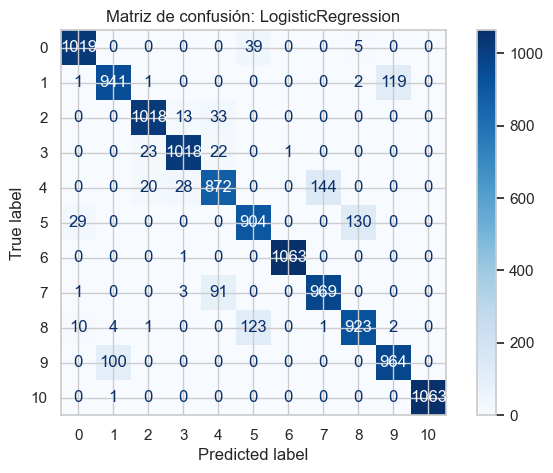


Modelo: RandomForest
Accuracy: 0.9989745342676466
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1063
           2       1.00      1.00      1.00      1064
           3       1.00      1.00      1.00      1064
           4       1.00      1.00      1.00      1064
           5       1.00      1.00      1.00      1064
           6       1.00      1.00      1.00      1063
           7       1.00      1.00      1.00      1064
           8       1.00      1.00      1.00      1064
           9       1.00      1.00      1.00      1064
          10       1.00      1.00      1.00      1064
          11       1.00      1.00      1.00      1064

    accuracy                           1.00     11702
   macro avg       1.00      1.00      1.00     11702
weighted avg       1.00      1.00      1.00     11702



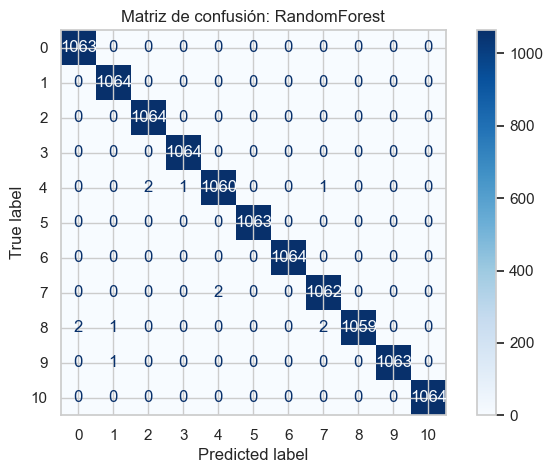

In [42]:
# 8) Evaluación detallada y matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

for name in results:
    print('\nModelo:', name)
    print('Accuracy:', results[name]['accuracy'])
    print(results[name]['report'])
    
    # Matriz de confusión
    model = models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusión: {name}')
    plt.show()


In [43]:
# 9) Ajuste de hiperparámetros (ejemplo para RandomForest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
}
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
gs.fit(X_train, y_train)
print('Mejor score:', gs.best_score_)
print('Mejores parámetros:', gs.best_params_)

best_rf = gs.best_estimator_


Mejor score: 0.9980768691800298
Mejores parámetros: {'max_depth': None, 'n_estimators': 100}


In [44]:
# 10) Prueba final con el mejor modelo
print('Reentrenando mejor RandomForest en todo el conjunto de entrenamiento...')
best_rf.fit(X_train, y_train)
y_pred_final = best_rf.predict(X_test)
print('Accuracy final:', accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final, zero_division=0))

# Guardar el modelo y el scaler
joblib.dump(best_rf, 'best_random_forest_sensorless.pkl')
joblib.dump(scaler, 'scaler_sensorless.pkl')
print('Modelos guardados: best_random_forest_sensorless.pkl, scaler_sensorless.pkl')


Reentrenando mejor RandomForest en todo el conjunto de entrenamiento...
Accuracy final: 0.9989745342676466
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1063
           2       1.00      1.00      1.00      1064
           3       1.00      1.00      1.00      1064
           4       1.00      1.00      1.00      1064
           5       1.00      1.00      1.00      1064
           6       1.00      1.00      1.00      1063
           7       1.00      1.00      1.00      1064
           8       1.00      1.00      1.00      1064
           9       1.00      1.00      1.00      1064
          10       1.00      1.00      1.00      1064
          11       1.00      1.00      1.00      1064

    accuracy                           1.00     11702
   macro avg       1.00      1.00      1.00     11702
weighted avg       1.00      1.00      1.00     11702

Modelos guardados: best_random_forest_sensorless.pkl, scaler_sensorless.pkl


# 11) Conclusiones y siguientes pasos
print('Resumen: se ha cargado el dataset, realizado EDA, entrenado modelos y ajustado hiperparámetros.')
print('Siguientes pasos sugeridos:\n- Realizar limpieza más profunda y detección de outliers.\n- Probar más modelos (SVM, XGBoost).\n- Evaluar tiempos de inferencia y optimizar para producción.\n- Validación cruzada más extensa y manejo de clases desbalanceadas si aplica.')
